In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('matlab.mplstyle')

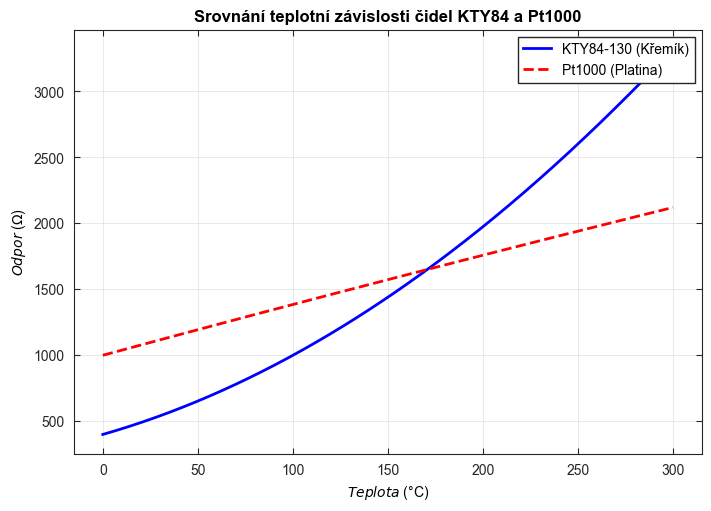

In [9]:
# Definice teplotního rozsahu (od -40 °C do 300 °C)
T = T = np.arange(0, 301, 1)

## 1. VÝPOČET PRO KTY84-130
R_ref_kty = 1000      # Nominální odpor při referenční teplotě [Ohm]
T_ref_kty = 100       # Referenční teplota [°C]
T_i = 250             # Bod zvratu [°C]

A_kty = 7.874e-3
B_kty = 1.874e-5
D_kty = -1.5e-6           

R_kty = np.zeros(np.size(T))

for i in range(len(T)):
    delta_T = T[i] - T_ref_kty
    if T[i] <= T_i:
        R_kty[i] = R_ref_kty * (1 + A_kty * delta_T + B_kty * delta_T**2)
    else:
        delta_Ti = T[i] - T_i
        R_kty[i] = R_ref_kty * (1 + A_kty * delta_T + B_kty * delta_T**2 + D_kty * delta_Ti**2)


## 2. VÝPOČET PRO Pt1000 (dle IEC 60751)
R0_pt = 1000          # Odpor při 0 °C [Ohm]
A_pt = 3.9083e-3
B_pt = -5.775e-7
C_pt = -4.183e-12     # Koeficient C se uplatňuje pouze pro T < 0 °C

R_pt = np.zeros(np.size(T))

for i in range(len(T)):
    if T[i] >= 0:
        # Rovnice pro kladné teploty
        R_pt[i] = R0_pt * (1 + A_pt * T[i] + B_pt * T[i]**2)
    else:
        # Rovnice pro záporné teploty
        R_pt[i] = R0_pt * (1 + A_pt * T[i] + B_pt * T[i]**2 + C_pt * (T[i] - 100) * T[i]**3)


## 3. VYKRESLENÍ GRAFU
plt.fig = plt.subplots(figsize=(7,5), layout='constrained')
plt.plot(T, R_kty, 'b-', linewidth = 2, label = 'KTY84-130 (Křemík)')
plt.plot(T, R_pt, 'r--', linewidth = 2, label = 'Pt1000 (Platina)')

# Formátování grafu
plt.title('Srovnání teplotní závislosti čidel KTY84 a Pt1000')
plt.xlabel('$Teplota$ (°C)')
plt.ylabel('$Odpor$ ($\Omega$)')

plt.legend()
plt.show()